In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as ans

In [2]:
df=pd.read_csv("/content/car_insurance_claims_dataset.csv")

In [3]:
df.head()

,claim_id,door_damaged,bonnet_damaged,bumper_damaged,dickey_damaged,fender_damaged,light_damaged,windshield_damaged,severity,total_parts_damaged,damage_score,estimated_repair_cost,insurance_payout
0,CLM000001,0,0,0,0,0,1,0,medium,1,1.509,16079.38,9582.52
1,CLM000002,0,1,1,0,0,0,0,medium,2,3.674,32431.04,25132.42
2,CLM000003,0,0,1,0,0,0,0,low,1,0.849,10471.33,129.75
3,CLM000004,0,0,1,1,1,0,0,medium,3,4.388,49370.67,37729.28
4,CLM000005,1,0,1,0,1,1,1,high,5,15.365,194765.01,141952.62


In [4]:
df['severity']=df['severity'].map({'medium':'moderate','high':'severe','low':'minor'})

In [5]:
df.head()

,claim_id,door_damaged,bonnet_damaged,bumper_damaged,dickey_damaged,fender_damaged,light_damaged,windshield_damaged,severity,total_parts_damaged,damage_score,estimated_repair_cost,insurance_payout
0,CLM000001,0,0,0,0,0,1,0,moderate,1,1.509,16079.38,9582.52
1,CLM000002,0,1,1,0,0,0,0,moderate,2,3.674,32431.04,25132.42
2,CLM000003,0,0,1,0,0,0,0,minor,1,0.849,10471.33,129.75
3,CLM000004,0,0,1,1,1,0,0,moderate,3,4.388,49370.67,37729.28
4,CLM000005,1,0,1,0,1,1,1,severe,5,15.365,194765.01,141952.62


In [6]:
df.columns

Index(['claim_id', 'door_damaged', 'bonnet_damaged', 'bumper_damaged',
       'dickey_damaged', 'fender_damaged', 'light_damaged',
       'windshield_damaged', 'severity', 'total_parts_damaged', 'damage_score',
       'estimated_repair_cost', 'insurance_payout'],
      dtype='object')

In [7]:
df.drop(['claim_id','damage_score','estimated_repair_cost'],axis=1,inplace=True)

In [8]:
df.head()

,door_damaged,bonnet_damaged,bumper_damaged,dickey_damaged,fender_damaged,light_damaged,windshield_damaged,severity,total_parts_damaged,insurance_payout
0,0,0,0,0,0,1,0,moderate,1,9582.52
1,0,1,1,0,0,0,0,moderate,2,25132.42
2,0,0,1,0,0,0,0,minor,1,129.75
3,0,0,1,1,1,0,0,moderate,3,37729.28
4,1,0,1,0,1,1,1,severe,5,141952.62


In [9]:
df.shape

(10000, 10)

# **EDA**

In [10]:
df.isnull().sum()

,0
door_damaged,0
bonnet_damaged,0
bumper_damaged,0
dickey_damaged,0
fender_damaged,0
light_damaged,0
windshield_damaged,0
severity,0
total_parts_damaged,0
insurance_payout,0


In [11]:
df["severity"].value_counts()

,count
severity,
moderate,3864
minor,3469
severe,2667


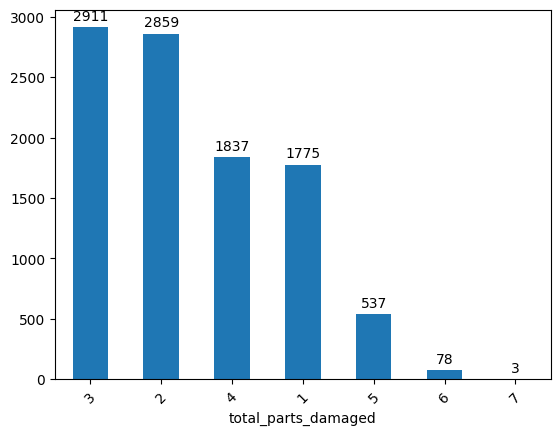

In [12]:
ax = df["total_parts_damaged"].value_counts().plot(kind="bar")
ax.set_xticklabels(ax.get_xticklabels(),rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.show()

In [13]:
df.columns

Index(['door_damaged', 'bonnet_damaged', 'bumper_damaged', 'dickey_damaged',
       'fender_damaged', 'light_damaged', 'windshield_damaged', 'severity',
       'total_parts_damaged', 'insurance_payout'],
      dtype='object')

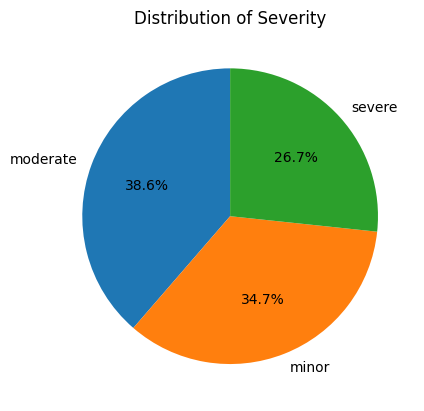

In [15]:
severity_counts = df['severity'].value_counts()
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Severity')
plt.show()

Model Building

In [16]:
df.head()

,door_damaged,bonnet_damaged,bumper_damaged,dickey_damaged,fender_damaged,light_damaged,windshield_damaged,severity,total_parts_damaged,insurance_payout
0,0,0,0,0,0,1,0,moderate,1,9582.52
1,0,1,1,0,0,0,0,moderate,2,25132.42
2,0,0,1,0,0,0,0,minor,1,129.75
3,0,0,1,1,1,0,0,moderate,3,37729.28
4,1,0,1,0,1,1,1,severe,5,141952.62


In [17]:
from sklearn.model_selection import train_test_split

In [20]:
x=df.drop("insurance_payout",axis=1)

In [21]:
y=df["insurance_payout"]

In [24]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
from sklearn.preprocessing import LabelEncoder

In [29]:
le = LabelEncoder()
x_train['severity'] = le.fit_transform(x_train['severity'])
x_test['severity'] = le.transform(x_test['severity'])

Label Enconding

# **Random Forest**

In [25]:
from sklearn.ensemble import RandomForestRegressor

In [26]:
rfr=RandomForestRegressor()

In [31]:
rfr.fit(x_train,y_train)

RandomForestRegressor()

In [32]:
rfr_pred=rfr.predict(x_test)

Random Forest Metrics

In [37]:
print("Train Accuracy:",rfr.score(x_train,y_train))
print("Test Accuracy:",rfr.score(x_test,y_test))

Train Accuracy: 0.7903529702510182
Test Accuracy: 0.7597402097633412


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, rfr_pred)
mse = mean_squared_error(y_test, rfr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rfr_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 14816.71
Mean Squared Error (MSE): 610328577.77
Root Mean Squared Error (RMSE): 24704.83
R-squared (R2): 0.76


Gradient Boosting

In [38]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(x_train, y_train)

GradientBoostingRegressor(random_state=42)

In [39]:
gbr_pred = gbr.predict(x_test)

In [41]:
print("Train Accuracy:",gbr.score(x_train,y_train))
print("Test Accuracy:",gbr.score(x_test,y_test))

Train Accuracy: 0.7842350601954877
Test Accuracy: 0.7649629465201312


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_gbr = mean_absolute_error(y_test, gbr_pred)
mse_gbr = mean_squared_error(y_test, gbr_pred)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test, gbr_pred)

print(f"Gradient Boosting Regressor Metrics:")
print(f"Mean Absolute Error (MAE): {mae_gbr:.2f}")
print(f"Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gbr:.2f}")
print(f"R-squared (R2): {r2_gbr:.2f}")

Gradient Boosting Regressor Metrics:
Mean Absolute Error (MAE): 14624.83
Mean Squared Error (MSE): 597061332.78
Root Mean Squared Error (RMSE): 24434.84
R-squared (R2): 0.76


Linear Regressor

In [42]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [43]:
lr_pred = lr.predict(x_test)

Model Metrics

In [44]:
print("Train Accuracy:",lr.score(x_train,y_train))
print("Test Accuracy:",lr.score(x_test,y_test))

Train Accuracy: 0.7203825326441232
Test Accuracy: 0.6981242922156072


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, lr_pred)
mse_lr = mean_squared_error(y_test, lr_pred)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, lr_pred)

print(f"Gradient Boosting Regressor Metrics:")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R-squared (R2): {r2_lr:.2f}")

Gradient Boosting Regressor Metrics:
Mean Absolute Error (MAE): 18064.38
Mean Squared Error (MSE): 766850629.53
Root Mean Squared Error (RMSE): 27692.07
R-squared (R2): 0.70


Adaptive Boosting

In [47]:
from sklearn.ensemble import AdaBoostRegressor

abr = AdaBoostRegressor(random_state=42)
abr.fit(x_train, y_train)

AdaBoostRegressor(random_state=42)

In [48]:
abr_pred = abr.predict(x_test)

In [49]:
print("Train Accuracy:",abr.score(x_train,y_train))
print("Test Accuracy:",abr.score(x_test,y_test))

Train Accuracy: 0.7108298580093444
Test Accuracy: 0.7050555658209712


In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_abr = mean_absolute_error(y_test, abr_pred)
mse_abr = mean_squared_error(y_test, abr_pred)
rmse_abr = np.sqrt(mse_abr)
r2_abr = r2_score(y_test, abr_pred)

print(f"Adaptive Boosting Regressor Metrics:")
print(f"Mean Absolute Error (MAE): {mae_abr:.2f}")
print(f"Mean Squared Error (MSE): {mse_abr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_abr:.2f}")
print(f"R-squared (R2): {r2_abr:.2f}")

Adaptive Boosting Regressor Metrics:
Mean Absolute Error (MAE): 17459.22
Mean Squared Error (MSE): 749243212.34
Root Mean Squared Error (RMSE): 27372.31
R-squared (R2): 0.71


In [51]:
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Linear Regression', 'Adaptive Boosting'],
    'MAE': [mae, mae_gbr, mae_lr, mae_abr],
    'MSE': [mse, mse_gbr, mse_lr, mse_abr],
    'RMSE': [rmse, rmse_gbr, rmse_lr, rmse_abr],
    'R2 Score': [r2, r2_gbr, r2_lr, r2_abr]
})

# Round the numeric columns to 2 decimal places for better readability
model_comparison = model_comparison.round(2)

print("\nModel Performance Comparison:")
print(model_comparison)


Model Performance Comparison:
               Model       MAE           MSE      RMSE  R2 Score
0      Random Forest  14816.71  6.103286e+08  24704.83      0.76
1  Gradient Boosting  14624.83  5.970613e+08  24434.84      0.76
2  Linear Regression  18064.38  7.668506e+08  27692.07      0.70
3  Adaptive Boosting  17459.22  7.492432e+08  27372.31      0.71


Best Model is Gradient Boosting

In [52]:
import pickle

# Save the Gradient Boosting model
filename = 'gradient_boosting_model.pkl'
pickle.dump(gbr, open(filename, 'wb'))

print(f"Gradient Boosting model saved to {filename}")

Gradient Boosting model saved to gradient_boosting_model.pkl
